Imports

In [44]:
from torchvision import datasets
from torchvision.transforms import ToTensor

Path Handling(Project Root)

In [45]:
from pathlib import Path
# Notebooks run from notebooks/, so define project root explicitly
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
DATA_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

Load MNIST

In [46]:
train_ds = datasets.MNIST(root=DATA_DIR, train = True, download= True, transform=ToTensor())
test_ds = datasets.MNIST(root=DATA_DIR, train = False, download= True, transform=ToTensor())

Quick Sanity Checks

In [47]:
len(train_ds), len(test_ds)

(60000, 10000)

In [48]:
img, label = train_ds[0]

In [49]:
img.shape
#1 --> means number of channels(grayscale). CNNs needs channels

torch.Size([1, 28, 28])

In [50]:
type(img)

torch.Tensor

In [51]:
type(label)

int

In [52]:
labels = train_ds.targets
labels.min(), labels.max()

(tensor(0), tensor(9))

In [53]:
dir(train_ds)

['__add__',
 '__annotations__',
 '__class__',
 '__class_getitem__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__orig_bases__',
 '__parameters__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_check_exists',
 '_check_legacy_exist',
 '_format_transform_repr',
 '_load_data',
 '_load_legacy_data',
 '_repr_indent',
 'class_to_idx',
 'classes',
 'data',
 'download',
 'extra_repr',
 'mirrors',
 'processed_folder',
 'raw_folder',
 'resources',
 'root',
 'target_transform',
 'targets',
 'test_data',
 'test_file',
 'test_labels',
 'train',
 'train_data',
 'train_labels',
 'training_file',
 'transform',
 'transforms']

In [54]:
X, y = train_ds.data, train_ds.targets
X.shape

torch.Size([60000, 28, 28])

In [55]:
y.shape

torch.Size([60000])

In [56]:
# Means: “Among all pixels in this image, what is the darkest pixel and what is the brightest pixel?”
print("Min pixel value(Darkest):", img.min().item())
print("Max pixel value(Brightest):", img.max().item())


Min pixel value(Darkest): 0.0
Max pixel value(Brightest): 1.0


Raw Data Inspection

In [57]:
import matplotlib.pyplot as plt
import matplotlib as mpl

In [58]:
def display(img, label=None, idx=None, filename=None):
    img_re = img.reshape(28, 28)

    plt.figure()
    plt.imshow(img_re, cmap=mpl.cm.binary, interpolation="nearest")
    plt.axis("off")

    title_parts = []
    if label is not None:
        title_parts.append(f"Label: {label}")
    if idx is not None:
        title_parts.append(f"Index: {idx}")

    if title_parts:
        plt.title(" | ".join(title_parts))

    if filename is not None:
        plt.savefig(PLOTS_DIR / filename, dpi=300, bbox_inches="tight")

    plt.show()


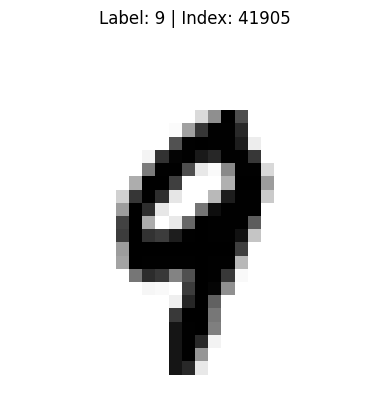

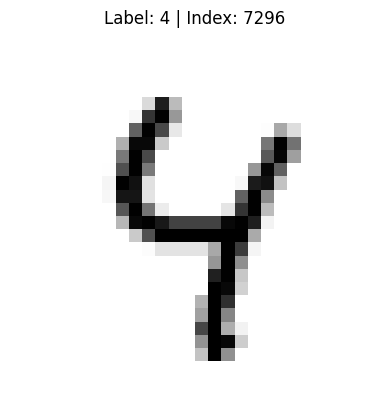

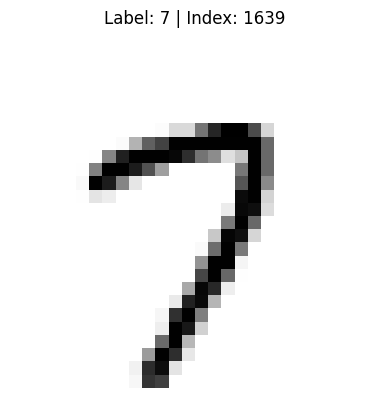

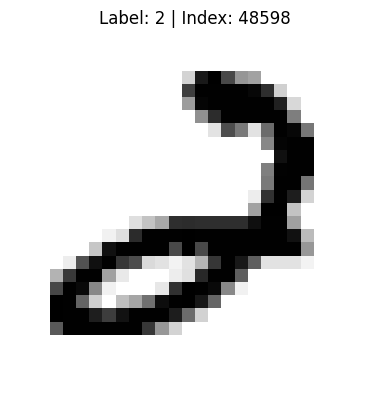

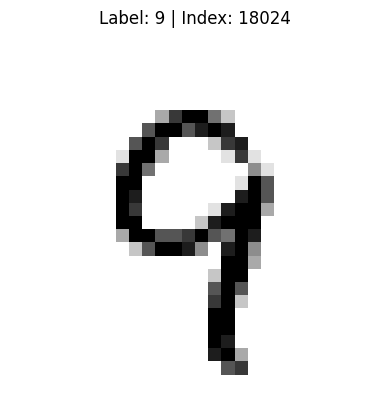

In [59]:
import random

random.seed(42)

for i in range(5):
    idx = random.randint(0, len(train_ds) - 1)
    img, label = train_ds[idx]

    filename = f"sample_{i}_digit_{label}_idx_{idx}.png"
    display(img, label=label, idx=idx, filename=filename)

Train/Validation/Test Split

In [60]:
import torch
from torch.utils.data import random_split

def split_train_val(dataset, train_size=50_000, val_size=10_000, seed=42):
    assert train_size + val_size == len(dataset)

    generator = torch.Generator().manual_seed(seed)
    train_set, val_set = random_split(
        dataset,
        [train_size, val_size],
        generator=generator
    )
    return train_set, val_set

In [61]:
train_set, val_set = split_train_val(train_ds)
test_set = test_ds

In [62]:
print("Train Set Size: ", len(train_set))
print("Validation Set Size: ", len(val_set))
print("Test Set Size: ", len(test_set))

Train Set Size:  50000
Validation Set Size:  10000
Test Set Size:  10000


Check digit distribution per split (class balance)
-If balance shifts badly: use a stratified split. In this case, it's fine

In [63]:
from collections import Counter
def counting_digit(dataset):
    labels = [label for _, label in dataset] #because dataset consists of images and labels
    return Counter(labels)
print("Elements distribution in Train Set: ", counting_digit(train_set))
print("Elements distribution in Validation Set: ", counting_digit(val_set))
print("Elements distribution in Test Set: ", counting_digit(test_set))

Elements distribution in Train Set:  Counter({1: 5613, 7: 5204, 3: 5093, 9: 4985, 2: 4958, 6: 4933, 0: 4923, 8: 4882, 4: 4863, 5: 4546})
Elements distribution in Validation Set:  Counter({1: 1129, 7: 1061, 3: 1038, 2: 1000, 0: 1000, 6: 985, 4: 979, 8: 969, 9: 964, 5: 875})
Elements distribution in Test Set:  Counter({1: 1135, 2: 1032, 7: 1028, 3: 1010, 9: 1009, 4: 982, 0: 980, 8: 974, 6: 958, 5: 892})


Normalization

In [64]:
from pprint import pprint
pprint({
    "type": type(img),
    "dtype": img.dtype,
    "shape": tuple(img.shape),
    "min": img.min().item(),
    "max": img.max().item(),
    "device": img.device,
    "contiguous": img.is_contiguous(),
})


{'contiguous': True,
 'device': device(type='cpu'),
 'dtype': torch.float32,
 'max': 1.0,
 'min': 0.0,
 'shape': (1, 28, 28),
 'type': <class 'torch.Tensor'>}


Reshaping

In [65]:
from torch.utils.data import DataLoader
batch_size = 64
train_loader = DataLoader(
    train_set, batch_size = batch_size, shuffle=True
)

In [66]:
images, labels = next(iter(train_loader))

In [67]:
print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


Random Samples Visualization

In [68]:
#pick random samples from the batch
k = 12
# Create shuffled indices [0, ..., batch_size-1] and take the first k to sample images randomly
torch.manual_seed(42)
idx = torch.randperm(images.size(0))[:k] 

In [69]:
#plot in a grid
cols = 6
rows = (k + cols -1) //cols

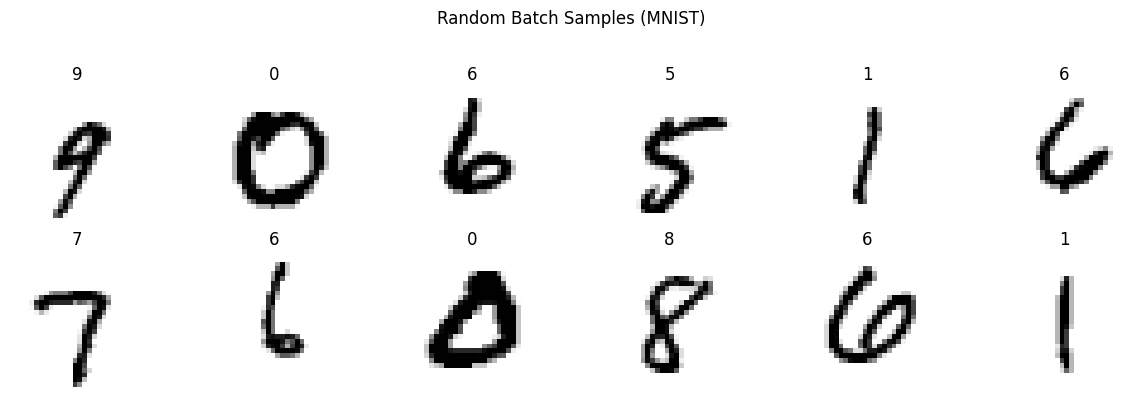

In [70]:
plt.figure(figsize = (12,4))
for i, j in enumerate(idx): 
    #i: 0,1,2...(The position in your plot)
    #j: the actual random batch index(which image to pick)
    plt.subplot(rows,cols, i+1)
    img = images[j].squeeze(0) # Remove the channel dimension (1, 28, 28 → 28, 28) for visualization only
    plt.imshow(img,cmap=mpl.cm.binary)
    plt.title(int(labels[j]))
    plt.axis("off")
plt.suptitle("Random Batch Samples (MNIST)")
plt.tight_layout(rect=[0, 0, 1, 0.95]) #rect=[left, bottom, right, top] space for different things

filename = "random_batch_visualization.png"
plt.savefig(PLOTS_DIR / filename, dpi=300, bbox_inches="tight")

plt.show()

One Sample per Digit
“Some digits (e.g., 7 and 1) show visual overlap even in single-sample inspection, suggesting inherent class ambiguity.”

In [85]:
torch.manual_seed(42)
one_per_digit = {}
for idx in range(len(train_set)):
    img, label = train_set[idx]
    digit = int(label) if not torch.is_tensor(label) else int(label.item())
    if digit not in one_per_digit:
        one_per_digit[digit] = (img, idx) #idx is saved for handy debugging, to refer back to the original dataset, where it came from
    if len(one_per_digit) == 10:
        break
#safety check
missing = [d for d in range(10) if d not in one_per_digit]
assert len(missing)== 0, f"Missing digits: {missing}" #assert condition, error_message

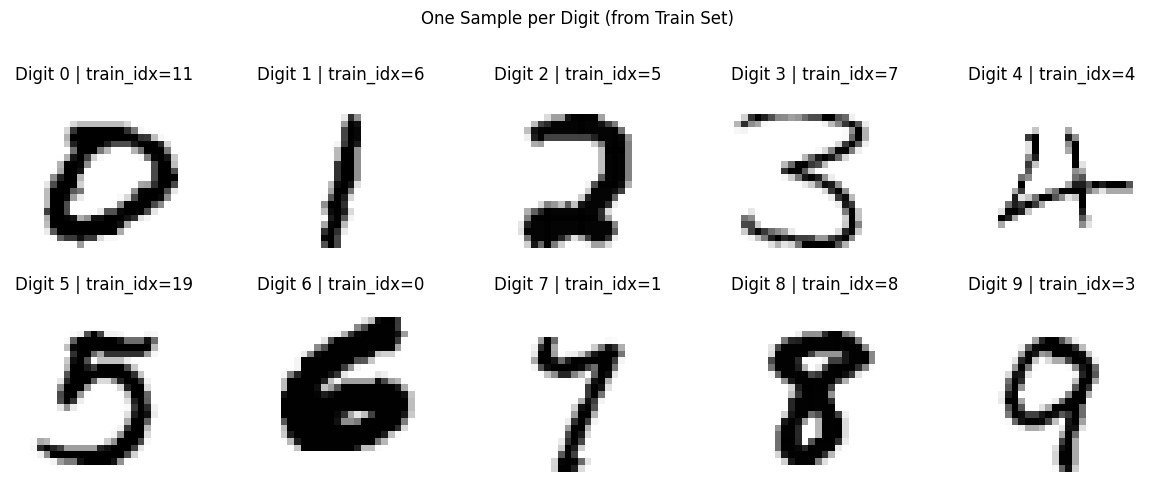

In [86]:
cols , rows = 5, 2
plt.figure(figsize=(12,5))

for d in range(10):
    img, idx = one_per_digit[d]
    plt.subplot(rows,cols,d+1)
    plt.imshow(img.squeeze(0),cmap = mpl.cm.binary)
    plt.title(f"Digit {d} | train_idx={idx}")
    plt.axis("off")

plt.suptitle("One Sample per Digit (from Train Set)")
plt.tight_layout(rect=[0, 0, 1, 0.95])


filename = "one_sample_per_digit_seed_42.png"
plt.savefig(PLOTS_DIR / filename, dpi=300, bbox_inches="tight")

plt.show()

In [73]:
#image 7 (i=1) looks slightly confusing. could be confused with number 1
# When you later see 1 ↔ 7 confusion, you’ll be able to say:

# “This isn’t just a model failure — it reflects intrinsic visual overlap observed during data inspection.”

Mean Image per Class

In [74]:
num_classes = 10
img_height, img_width = 28,28
# Accumulators
class_sums = torch.zeros(num_classes, img_height, img_width) #creates a tensor of shape [10,28,28] all 0
class_counts = torch.zeros(num_classes)

In [75]:
# Disable gradients
with torch.no_grad(): #Tells PyTorch: “I am not training a model right now.”
    for images, labels in train_loader:
        # images: [B, 1, 28, 28]
        images = images.squeeze(1)  # -> [B, 28, 28]

        for i in range(images.size(0)): #Iterates over each image in the batch
            label = labels[i].item()
            class_sums[label] += images[i]
            class_counts[label] += 1

In [76]:
class_means = class_sums / class_counts.view(-1, 1, 1) # changed class_counts original shape [10]---->[10,1,1]
# PyTorch expands [1,1] → [28,28] automatically.
# Result:

# Each pixel of digit d is divided by the number of samples of digit d
class_means.shape

torch.Size([10, 28, 28])

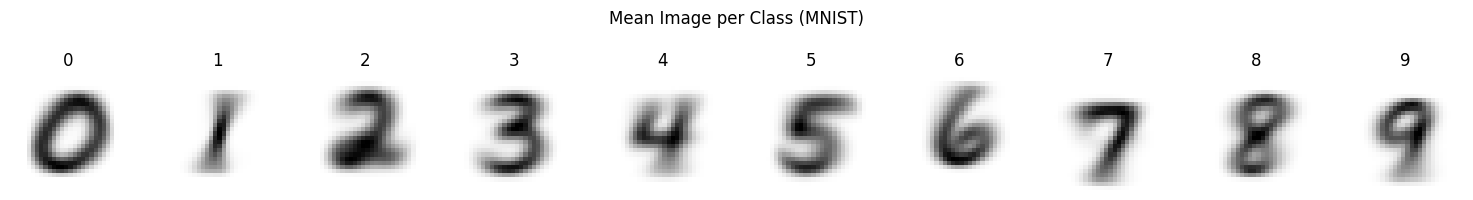

In [87]:
fig, axes = plt.subplots(1, 10, figsize=(15, 2))

for digit in range(10):
    axes[digit].imshow(class_means[digit], cmap=mpl.cm.binary)
    axes[digit].set_title(str(digit))
    axes[digit].axis('off')

plt.suptitle("Mean Image per Class (MNIST)")
plt.tight_layout(rect=[0, 0, 1, 0.9])

filename = "mean_image_per_class.png"
plt.savefig(PLOTS_DIR / filename, dpi=300, bbox_inches="tight")

plt.show()

## Interpretation: Mean Image per Class (MNIST)

Each panel shows the **pixel-wise average of all training images** belonging to a given digit.

### What the Brightness Means
- **Brighter pixels** indicate locations where many images of that digit contain a stroke.
- **Darker pixels** indicate background regions for that digit.
- **Gray pixels** indicate areas where strokes appear inconsistently across different handwriting styles.

### What to Observe in the Figure
- Each digit forms a clear **canonical shape**, showing that MNIST digits are well-centered and consistently aligned.
- Digits with **thin, sharp structures** (e.g., `1`) show concentrated bright regions, indicating low variability.
- Digits with **thicker or blurrier strokes** (e.g., `5`, `9`) indicate higher variation in how people write those digits.
- Apparent stroke thickness reflects **spatial variability**, not actual pen thickness.

### What This Tells Us About the Dataset
- MNIST has strong structural regularities that a classifier can exploit.
- Some digits exhibit higher intra-class variability, which can make them harder to classify.
- The dataset contains mild biases (e.g., slight tilt or asymmetry) that models may implicitly learn.

### What This Figure Does *Not* Show
- Individual handwriting styles
- Rare or unusual stroke patterns
- Spatial relationships beyond pixel-wise averages

**Summary:**  
This visualization acts as a *heatmap of where each digit is most likely to appear*, providing a powerful sanity check and intuition about class structure and variability in the dataset.


In [78]:
print(class_counts)
print(class_means.min().item(), class_means.max().item())

tensor([4923., 5613., 4958., 5093., 4863., 4546., 4933., 5204., 4882., 4985.])
0.0 0.9665660858154297


Pixel Intensity Histogram

In [79]:
all_pixels = []
with torch.no_grad():
    for images, _ in train_loader:
        # images: [B, 1, 28, 28]
        all_pixels.append(images.view(-1)) #turns [B,1,28,28] into a 1D vector containing every pixel value from that batch

In [80]:
# Concatenate into one long vector
all_pixels = torch.cat(all_pixels) #now you get one huge tensor like [num_images * 28 * 28]

In [81]:
print(all_pixels.shape)  # sanity check


torch.Size([39200000])


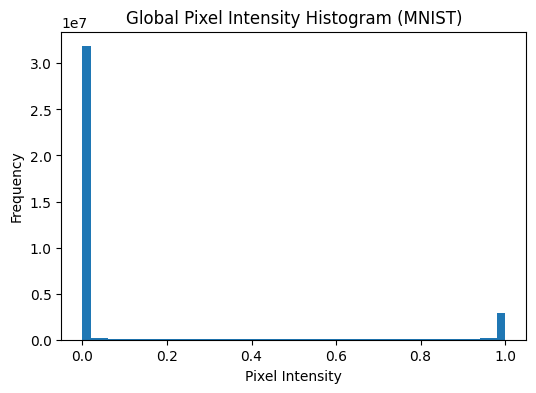

In [88]:
plt.figure(figsize=(6, 4))
plt.hist(all_pixels.numpy(), bins=50)
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.title("Global Pixel Intensity Histogram (MNIST)")

filename = "global_pixel_intensity_histogram.png"
plt.savefig(PLOTS_DIR / filename, dpi=300, bbox_inches="tight")

plt.show()

## How to Interpret the Global Pixel Intensity Histogram (MNIST)

MNIST images are grayscale, so pixel intensities represent how dark or bright each pixel is.

### Typical MNIST Characteristics
- **A huge spike near 0**  
  Represents the black background of the images.
- **A long tail toward higher values**  
  Represents the white or light-gray strokes forming the digits.

### Interpretation Patterns

- **Big spike near 0**  
  → Most pixels are background. This is completely normal for MNIST.

- **Many values near 1**  
  → Digits have strong bright strokes, or the dataset has been normalized to the range \([0, 1]\).

- **Values outside the expected range**  
  → If you expected pixel values in \([0, 1]\) but see values like 200 or higher, the data was likely not normalized or tensorized as intended.

- **Histogram appears “flat-ish”**  
  → This is unusual for MNIST and may indicate heavy preprocessing, data augmentation, or an unexpected transformation applied to the images.


Per-class histogram (example: 1 vs 7)

In [83]:

pixels_1 = []
pixels_7 = []

with torch.no_grad():
    for images, labels in train_loader:
        images = images.view(images.size(0), -1)  # [B, 784]

        for i in range(images.size(0)):
            if labels[i] == 1:
                pixels_1.append(images[i])
            elif labels[i] == 7:
                pixels_7.append(images[i])

pixels_1 = torch.cat(pixels_1)
pixels_7 = torch.cat(pixels_7)


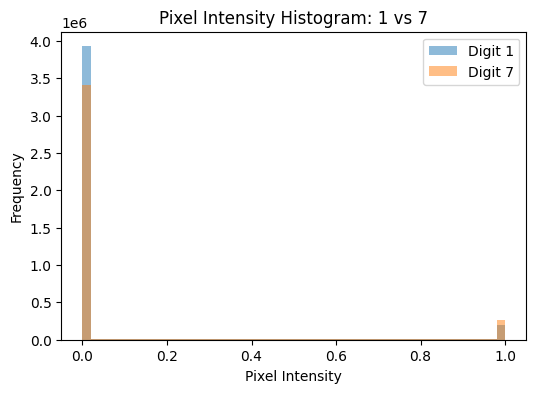

In [89]:
plt.figure(figsize=(6, 4))
plt.hist(pixels_1.numpy(), bins=50, alpha=0.5, label='Digit 1')
plt.hist(pixels_7.numpy(), bins=50, alpha=0.5, label='Digit 7')
plt.legend()
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.title("Pixel Intensity Histogram: 1 vs 7")

filename = "pixel_intensity_histogram_1_vs_7.png"
plt.savefig(PLOTS_DIR / filename, dpi=300, bbox_inches="tight")

plt.show()


## How to Interpret the Per-Class Pixel Intensity Histogram (Digit 1 vs Digit 7)

This histogram compares the distribution of pixel intensities for two specific classes: digit **1** and digit **7**.  
Instead of looking at all pixels together, we examine how much “ink” each digit tends to use.

### Why This Comparison Is Useful
- Helps reveal class-specific intensity patterns
- Shows whether some digits are systematically brighter or sparser
- Provides intuition about why certain digits may be easier or harder to classify

### Interpretation Patterns

- **Digit 1 has a larger spike near 0**  
  → Digit **1** is typically thin and sparse, with many background pixels and fewer bright stroke pixels.

- **Digit 7 shows more mid-to-high intensity values**  
  → Digit **7** usually covers more area (top bar and diagonal), resulting in more non-zero and brighter pixels.

- **Strong overlap between the two histograms**  
  → Pixel intensity alone is not sufficient to distinguish the digits; spatial structure and shape matter more.

- **One histogram consistently shifted to the right**  
  → That digit tends to have brighter or thicker strokes on average.

### Important Limitation
Pixel intensity histograms ignore **spatial information**.  
Two digits can have very similar intensity distributions while having completely different shapes.  
Therefore, these plots are best used for **data understanding and sanity checks**, not for direct classification.


Observations & Answers

## Observations & Answers

This section summarizes the key insights obtained from exploratory analysis of the MNIST dataset and explains their implications for model training and evaluation.

---

### 1. Dataset Integrity and Structure

- The MNIST dataset is clean, well-structured, and standardized.
- Each image is a 28×28 grayscale tensor with values normalized to the range [0, 1].
- All samples are consistently centered and aligned, with minimal background noise.

**Interpretation:**  
The dataset requires no additional preprocessing for basic training. Its standardized format ensures that observed model behavior is driven by learning rather than data quality issues.

---

### 2. Train–Validation–Test Split and Class Balance

- The training, validation, and test splits maintain approximately uniform class distributions.
- No digit class is significantly over- or under-represented.

**Interpretation:**  
Class balance ensures that accuracy is a reliable evaluation metric and that the model will not develop bias toward specific digits. Stratified sampling is unnecessary in this case.

---

### 3. Visual Characteristics of Digits

- Digits exhibit consistent spatial positioning and scale.
- Some digits (e.g., 1 and 7) show visual similarity even in isolated samples.
- Handwriting variability exists but remains within recognizable limits.

**Interpretation:**  
Certain classification errors are expected due to intrinsic ambiguity in the data rather than model failure. This provides context for interpreting confusion matrices later.

---

### 4. Mean Image per Class

- Pixel-wise averaging produces clear canonical shapes for each digit.
- Digits such as 1 show concentrated strokes, indicating low variability.
- Digits such as 5 and 9 display blurrier averages, indicating higher intra-class variation.

**Interpretation:**  
MNIST contains strong structural regularities that models can exploit. However, digits with higher variability are inherently harder to classify and may show lower accuracy.

---

### 5. Pixel Intensity Distribution (Global)

- A large proportion of pixels have values near 0, representing background.
- Foreground strokes occupy a relatively small fraction of pixels.
- The long tail toward higher intensities corresponds to digit strokes.

**Interpretation:**  
The sparsity of foreground pixels highlights the importance of spatial feature extraction. Models that rely only on pixel intensity statistics will be insufficient.

---

### 6. Per-Class Pixel Intensity Comparison (Digit 1 vs Digit 7)

- Digit 1 has a higher proportion of background pixels.
- Digit 7 shows more mid-to-high intensity pixels due to larger stroke coverage.
- Significant overlap exists between the two distributions.

**Interpretation:**  
Pixel intensity alone cannot reliably distinguish digits. Spatial structure and shape information are critical, reinforcing the need for convolutional architectures.

---

### 7. Overall Implications for Modeling

- MNIST is well-suited for convolutional neural networks due to its spatial regularity.
- Some misclassifications are unavoidable due to inherent visual overlap between classes.
- High accuracy is achievable, but perfect classification is unrealistic.

**Final Conclusion:**  
The exploratory analysis confirms that MNIST is a balanced, clean, and structured dataset with meaningful intra-class variation and intrinsic class ambiguity. These properties explain both the strengths and limitations of models trained on this dataset and provide a clear baseline for interpreting training and evaluation results.
